# Classificação com Rede Neural MLP (Multilayer Perceptron)

## O que é uma Rede Neural

Uma **rede neural artificial** é um modelo computacional inspirado no funcionamento do cérebro humano. Ela é composta por unidades básicas chamadas **neurônios artificiais** (ou nós), organizados em **camadas** que processam informações de forma sequencial.

Uma rede MLP (Multilayer Perceptron) é a arquitetura mais fundamental de rede neural. Ela é composta por:

- Uma **camada de entrada** (*input layer*): recebe os dados brutos (as features)
- Uma ou mais **camadas ocultas** (*hidden layers*): aprendem representações intermediárias dos dados
- Uma **camada de saída** (*output layer*): produz a predição final

<mark>O MLP é o ponto de partida ideal para entender redes neurais, pois todos os conceitos essenciais - neurônio, peso, bias, ativação, backpropagation - estão presentes de forma direta e transparente.</mark>

### O neurônio artificial

Cada neurônio realiza uma operação simples em duas etapas:

**1. Combinação linear** - multiplica cada entrada pelo seu peso (*weight*) e soma um viés (*bias*):

$$z = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b = \mathbf{w} \cdot \mathbf{x} + b$$

**2. Função de ativação** - aplica uma transformação não-linear ao resultado:

$$\hat{y} = f(z)$$

Os **pesos** e o **bias** são os parâmetros que a rede aprende durante o treinamento. A **função de ativação** é o que permite à rede aprender relações não-lineares nos dados - sem ela, empilhar camadas não teria utilidade (o resultado seria sempre uma função linear).

### Funções de ativação

As funções de ativação mais comuns em redes neurais modernas são:

| Função | Fórmula | Uso típico |
|--------|---------|-----------|
| **ReLU** | $f(z) = \max(0, z)$ | Camadas ocultas (padrão atual) |
| **Sigmoid** | $f(z) = \frac{1}{1 + e^{-z}}$ | Saída binária (probabilidade) |
| **Softmax** | $f(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$ | Saída multiclasse |
| **Tanh** | $f(z) = \tanh(z)$ | Camadas recorrentes |

Neste notebook utilizaremos **ReLU** nas camadas ocultas - ela é simples, eficiente e resolve o problema do gradiente que desaparece (*vanishing gradient*) que afeta a Sigmoid em redes profundas.

### Como a rede aprende - Backpropagation

O treinamento de uma rede neural ocorre em um ciclo repetido chamado **época** (*epoch*):

1. **Forward pass** - os dados passam pela rede da entrada à saída, gerando uma predição $\hat{y}$
2. **Cálculo do erro** - a **função de perda** (*loss function*) mede o quão errada foi a predição: $\mathcal{L}(\hat{y}, y)$
3. **Backward pass** - o algoritmo de **backpropagation** calcula o gradiente da perda em relação a cada parâmetro usando a regra da cadeia do cálculo diferencial
4. **Atualização dos pesos** - o **otimizador** (ex: Adam, SGD) ajusta os pesos na direção oposta ao gradiente para reduzir o erro

$$w \leftarrow w - \eta \cdot \frac{\partial \mathcal{L}}{\partial w}$$

onde $\eta$ é a **taxa de aprendizado** (*learning rate*) - um hiperparâmetro que controla o tamanho do passo de atualização.

O PyTorch automatiza os passos 3 e 4 com `loss.backward()` e `optimizer.step()`.



### O que significa a derivada parcial na função de perda?

**O que é derivada parcial?**<br />
Uma derivada mede *"se eu mudar essa variável um pouquinho, quanto a função muda?"*

Quando uma função depende de **múltiplas variáveis**, a derivada **parcial** em relação a uma delas mede o efeito de mudar *só aquela*, mantendo todas as outras fixas. O símbolo $\partial$ (lê-se "del") indica isso - em contraste com $d$ da derivada ordinária.

**Parcial a quê?**<br />
A função de perda $\mathcal{L}$ depende de **todos os pesos da rede** simultaneamente - pode ser milhares ou milhões de parâmetros: $w_1, w_2, \ldots, w_n$.

$$\frac{\partial \mathcal{L}}{\partial w}$$

significa: *"mantendo todos os outros pesos fixos, se eu mudar este peso $w$ um pouquinho, quanto a perda aumenta ou diminui?"*

A resposta é um número - o **gradiente local** daquele peso. Se for positivo, aumentar $w$ aumenta o erro; se for negativo, aumentar $w$ diminui o erro.

**Por que subtrair?**<br />
O sinal de **menos** é o que faz o truque: mover $w$ na direção **oposta** ao gradiente garante que a perda diminua. Isso é o **gradiente descendente** - descer a "encosta" da superfície de erro.

$\eta$ (learning rate) controla o tamanho do passo - muito grande e o modelo "pula" o mínimo; muito pequeno e demora para convergir.

### Leitura adicional

Para uma explicação visual e intuitiva de como cada componente funciona, recomenda-se:

- [But what is a neural network? - 3Blue1Brown](https://www.youtube.com/watch?v=aircAruvnKk)
- [Gradient descent, how neural networks learn - 3Blue1Brown](https://www.youtube.com/watch?v=IHZwWFHWa-w)
- [Backpropagation calculus - 3Blue1Brown](https://www.youtube.com/watch?v=tIeHLnjs5U8)

## Classificação com MLP

### Dados utilizados

O conjunto de dados utilizado é o mesmo do notebook de finetuning do BERT: o [Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic).

Aqui, porém, usaremos as **features numéricas** extraídas das imagens - raio, textura, perímetro, área, etc. - em vez dos laudos em texto. Isso torna o problema mais simples e direto, ideal para demonstrar o MLP sem a complexidade de processar linguagem natural.

### Preparação dos dados

A preparação dos dados está no notebook [PrepareData](PrepareData.ipynb).

Os dados devem estar salvos em `../data/breast_cancer.parquet` antes de executar este notebook.

### Verificar software e hardware disponível

In [24]:
import torch

print("Versão do PyTorch: ", torch.__version__)
print("CUDA disponível: ", torch.cuda.is_available())
print("Versão do CUDA: ", torch.version.cuda)

Versão do PyTorch:  2.12.0+cu132
CUDA disponível:  True
Versão do CUDA:  13.2


### Aquisição dos dados

In [25]:
import pandas as pd

# Features numéricas utilizadas como entrada da rede
FEATURE_COLUMNS = [
    "radius", "texture", "perimeter", "area",
    "smoothness", "compactness", "concavity",
    "concave points", "symmetry", "fractal dimension"
]

def preprocess_dataset(path):
    df = pd.read_parquet(path)

    # Codificar o diagnóstico: Maligno=1, Benigno=0
    df['diagnosis_encoded'] = df['diagnosis'].apply(lambda x: 1 if x == 'M' else 0)

    return df

data = preprocess_dataset("../data/breast_cancer.parquet")

data[['id_number', 'diagnosis', 'diagnosis_encoded'] + FEATURE_COLUMNS].head()

,id_number,diagnosis,diagnosis_encoded,radius,texture,perimeter,area,smoothness,compactness,concavity,concave points,symmetry,fractal dimension
0,842302,M,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871
1,842517,M,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667
2,84300903,M,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999
3,84348301,M,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744
4,84358402,M,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883


### Distribuição de diagnósticos

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem de cada classe
data["diagnosis"].value_counts()


diagnosis
B    357
M    212
Name: count, dtype: int64

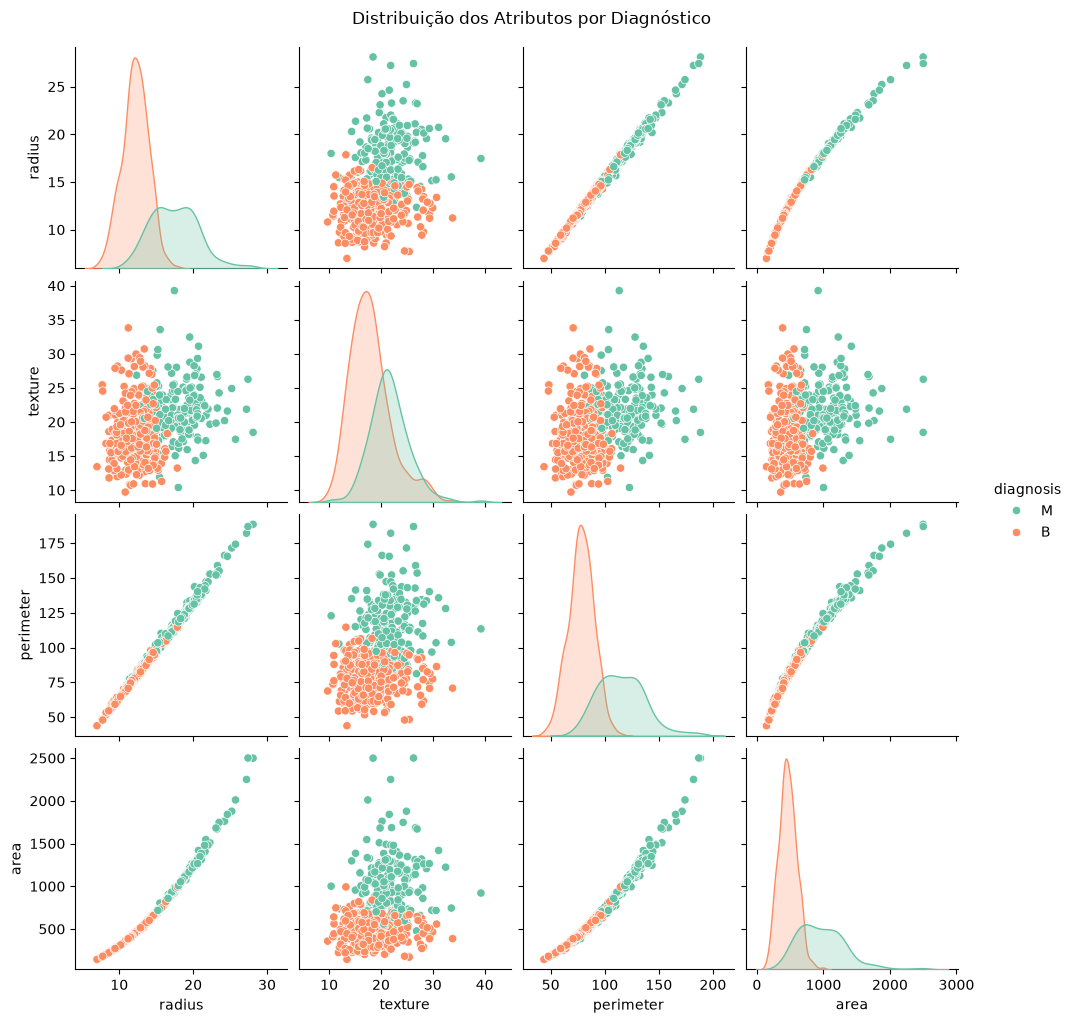

In [27]:
sns.pairplot(data, hue='diagnosis', vars=['radius', 'texture', 'perimeter', 'area'], palette='Set2')
plt.suptitle("Distribuição dos Atributos por Diagnóstico", y=1.02)
plt.show()

### Normalização dos dados

As features têm escalas muito diferentes (ex: `area` pode ser 1000x maior que `smoothness`). Redes neurais são sensíveis à escala das entradas - gradientes de features com valores muito grandes dominariam o aprendizado.

A **normalização** resolve isso: a `StandardScaler` subtrai a média e divide pelo desvio padrão, fazendo com que cada feature tenha média 0 e desvio padrão 1.

> **Atenção:** o scaler deve ser ajustado **apenas nos dados de treino** e depois aplicado aos dados de validação - para evitar *data leakage* (vazamento de informação do conjunto de teste para o modelo).

### Divisão dos dados em treino e teste

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data[FEATURE_COLUMNS].values
y = data['diagnosis_encoded'].values

# Dividir em treino (80%) e validação (20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar: ajusta no treino, aplica no treino e validação
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

print(f"Treino:    {X_train.shape[0]} amostras")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Features:  {X_train.shape[1]}")

Treino:    455 amostras
Validação: 114 amostras
Features:  10


### Criar Datasets e Dataloaders

In [29]:
from torch.utils.data import TensorDataset, DataLoader

# Converter arrays NumPy para tensores do PyTorch
train_inputs  = torch.tensor(X_train, dtype=torch.float32)
train_labels  = torch.tensor(y_train, dtype=torch.long)
val_inputs    = torch.tensor(X_val,   dtype=torch.float32)
val_labels    = torch.tensor(y_val,   dtype=torch.long)

# Agrupar features e rótulos em Datasets
train_dataset = TensorDataset(train_inputs, train_labels)
val_dataset   = TensorDataset(val_inputs,   val_labels)

batch_size = 16

# DataLoaders: iteram sobre os dados em batches durante o treinamento
train_dataloader = DataLoader(train_dataset, shuffle=True,  batch_size=batch_size)
val_dataloader   = DataLoader(val_dataset,   shuffle=False, batch_size=batch_size)

### Definição do modelo

A arquitetura escolhida é intencionalmente reduzida para fins didáticos:

```
Entrada (10 features)
    ↓    
Camada Linear:  10 → 16  +  ReLU
    ↓    
Camada Linear:  16 →  8  +  ReLU
    ↓    
Camada Linear:   8 →  2  (logits: Benigno / Maligno)
```

**10 (entrada)**<br />
As 10 features numéricas extraídas das imagens (raio, textura, perímetro, área, etc).

**10 → 16 (expansão)**<br />
A rede precisa de "espaço" para aprender combinações das 10 features originais. Com apenas 10 neurônios na camada oculta, cada neurônio ficaria "responsável" por aproximadamente uma feature - não sobraria capacidade para aprender interações entre elas (ex: "raio grande e textura irregular"). Ir para 16 cria esse espaço extra para representações intermediárias mais ricas.

**16 → 8 (compressão)**<br />
Depois de expandir, comprimir força a rede a destilar o que aprendeu. Ela precisa jogar fora o que é ruído e manter apenas o que realmente discrimina as classes. É um gargalo intencional - parecido com o conceito de encoder em autoencoders. Empiricamente, esse padrão "ampulheta" tende a generalizar melhor do que manter tamanho constante.

**8 → 2 (saída)**<br />
Um score bruto (logit) para cada classe.

**O padrão geral é:**<br />
entrada → expansão → compressão → saída

**Sobre os números**<br />
Sobre os números específicos (16 e 8): eles são heurísticos - potências de 2 são convencionais (alinham bem com hardware) e o fator de redução ~2x a cada camada é uma regra de bolso comum. Não existe uma fórmula exata; em produção isso seria um hiperparâmetro a ser buscado com cross-validation.

Uma alternativa igualmente válida seria 10→32→16→2 (mais capacidade) ou 10→8→2 (mais simples) - dependendo da complexidade do problema. Para 569 amostras e 10 features como neste dataset, a arquitetura atual já é suficientemente expressiva sem overfitting.

Em PyTorch, modelos são definidos como classes que herdam de `nn.Module`. O método `forward` descreve como os dados fluem pela rede (o *forward pass*).

In [30]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),  # Camada 1: input_size → 16 neurônios
            nn.ReLU(),                  # Ativação ReLU
            nn.Linear(16, 8),           # Camada 2: 16 → 8 neurônios
            nn.ReLU(),                  # Ativação ReLU
            nn.Linear(8, 2)             # Camada de saída: 8 → 2 classes
        )

    def forward(self, x):
        return self.network(x)


input_size = len(FEATURE_COLUMNS)  # 10 features
model = MLP(input_size)

print(model)
print(f"\nTotal de parâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

MLP(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
)

Total de parâmetros treináveis: 330


### Otimizador e função de perda

In [ ]:
# CrossEntropyLoss: combina Softmax + NLLLoss - ideal para classificação multiclasse
criterion = nn.CrossEntropyLoss()

# Adam: otimizador adaptativo, geralmente converge mais rápido que SGD simples
# lr (learning rate): tamanho do passo de atualização dos pesos
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

### Treinamento do modelo

In [32]:
from tqdm import tqdm

# Selecionar o dispositivo: GPU se disponível, senão CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 10

# Histórico para visualização posterior
history = {"loss": [], "val_accuracy": []}

for epoch in tqdm(range(epochs), desc="Treinamento"):

    # ── Treinamento ──────────────────────────────────────────────────────────
    model.train()  # Ativa modo de treino (habilita dropout, batch norm, etc.)
    total_loss = 0

    for batch_inputs, batch_labels in train_dataloader:

        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)

        # 1. Zerar os gradientes acumulados do passo anterior
        optimizer.zero_grad()

        # 2. Forward pass: calcular predições
        logits = model(batch_inputs)

        # 3. Calcular a perda
        loss = criterion(logits, batch_labels)

        # 4. Backward pass: calcular gradientes via backpropagation
        loss.backward()

        # 5. Atualizar os pesos com o otimizador
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_dataloader)

    # ── Validação ────────────────────────────────────────────────────────────
    model.eval()  # Desativa comportamentos exclusivos do treino
    total_correct = 0
    total_samples = 0

    with torch.no_grad():  # Desativa cálculo de gradientes (mais rápido)
        for batch_inputs, batch_labels in val_dataloader:

            batch_inputs = batch_inputs.to(device)
            batch_labels = batch_labels.to(device)

            logits      = model(batch_inputs)
            predictions = torch.argmax(logits, dim=-1)

            total_correct += (predictions == batch_labels).sum().item()
            total_samples += batch_labels.size(0)

    val_accuracy = total_correct / total_samples

    history["loss"].append(avg_loss)
    history["val_accuracy"].append(val_accuracy)

    tqdm.write(f"Epoch {epoch + 1:02d}/{epochs}  |  Loss: {avg_loss:.4f}  |  Val Acurácia: {val_accuracy:.2%}")

Treinamento:  10%|█         | 1/10 [00:00<00:01,  5.83it/s]

Epoch 01/10  |  Loss: 0.7080  |  Val Acurácia: 37.72%


Treinamento:  20%|██        | 2/10 [00:00<00:01,  5.88it/s]

Epoch 02/10  |  Loss: 0.6312  |  Val Acurácia: 91.23%


Treinamento:  40%|████      | 4/10 [00:00<00:00,  9.77it/s]

...

Epoch 06/10  |  Loss: 0.2073  |  Val Acurácia: 94.74%


Treinamento:  80%|████████  | 8/10 [00:00<00:00, 12.97it/s]

Epoch 07/10  |  Loss: 0.1783  |  Val Acurácia: 96.49%
Epoch 08/10  |  Loss: 0.1646  |  Val Acurácia: 96.49%
Epoch 09/10  |  Loss: 0.1572  |  Val Acurácia: 95.61%


Treinamento: 100%|██████████| 10/10 [00:00<00:00, 11.59it/s]

Epoch 10/10  |  Loss: 0.1534  |  Val Acurácia: 96.49%


### Curvas de aprendizado

As curvas de aprendizado mostram como a rede evoluiu ao longo das épocas:

- **Loss (treino)** - deve cair progressivamente. Uma queda suave indica que o otimizador está encontrando um mínimo de forma estável.
- **Acurácia (validação)** - pode parecer estável mesmo com a loss caindo, pois a acurácia é discreta (cada erro vale ~0.88% nesse dataset). O que a loss está mostrando é que o modelo está ficando **mais confiante** nas predições corretas, não apenas acertando mais.

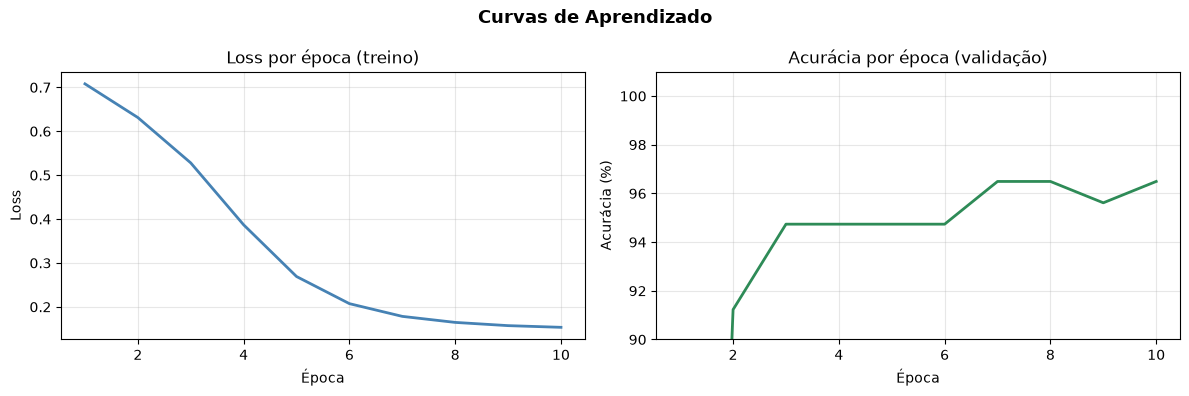

In [33]:
epoch_range = range(1, epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ── Loss ────────────────────────────────────────────────────────────────────
ax1.plot(epoch_range, history["loss"], color="steelblue", linewidth=2)
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.set_title("Loss por época (treino)")
ax1.grid(True, alpha=0.3)

# ── Acurácia ────────────────────────────────────────────────────────────────
ax2.plot(epoch_range, [v * 100 for v in history["val_accuracy"]], color="seagreen", linewidth=2)
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia (%)")
ax2.set_title("Acurácia por época (validação)")
ax2.set_ylim(90, 101)
ax2.grid(True, alpha=0.3)

plt.suptitle("Curvas de Aprendizado", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Avaliação do modelo

In [34]:
y_test  = []
y_pred  = []
y_proba = []

model.eval()

with torch.no_grad():
    for batch_inputs, batch_labels in val_dataloader:

        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)

        logits = model(batch_inputs)

        y_test.extend(batch_labels.cpu().numpy())

        preds = torch.argmax(logits, dim=-1)
        y_pred.extend(preds.cpu().numpy())

        # Probabilidade da classe positiva (Maligno = 1)
        y_proba.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())

#### Acurácia, Precisão, Recall e F1

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)

print(f"Acurácia:  {accuracy:.2f}")
print(f"Precisão:  {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")
print(f"ROC AUC:   {roc_auc:.2f}")

Acurácia:  0.96
Precisão:  0.98
Recall:    0.93
F1 Score:  0.95
ROC AUC:   0.99


#### Relatório de classificação

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Benigno", "Maligno"]))

              precision    recall  f1-score   support

     Benigno       0.96      0.99      0.97        71
     Maligno       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



#### Matriz de confusão

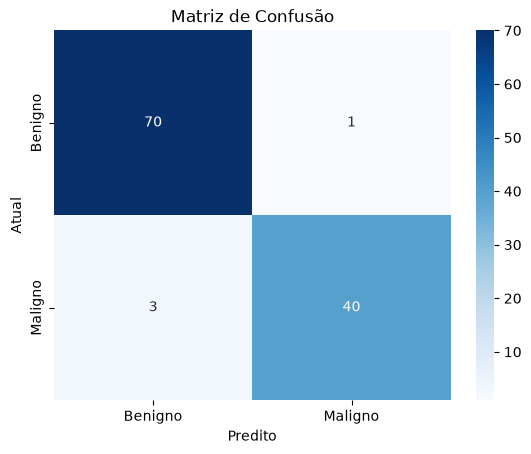

In [37]:
from sklearn.metrics import confusion_matrix

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"]
)
plt.xlabel('Predito')
plt.ylabel('Atual')
plt.title('Matriz de Confusão')
plt.show()

#### Curva Precision-Recall

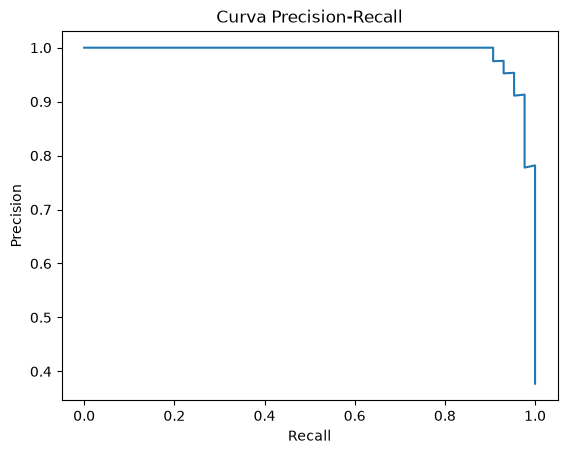

In [38]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)

plt.plot(recall_curve, precision_curve)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.show()

#### Curva ROC

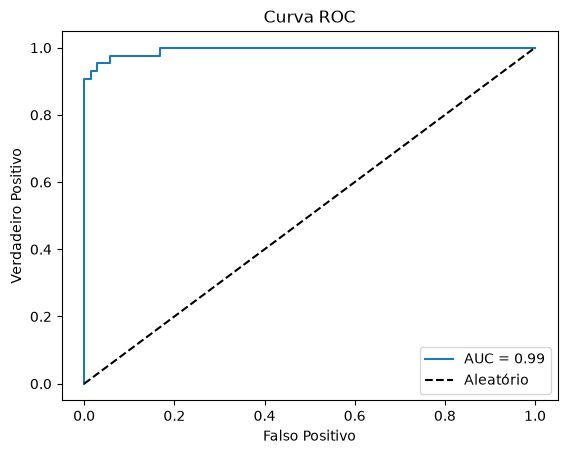

In [39]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--', label="Aleatório")
plt.xlabel('Falso Positivo')
plt.ylabel('Verdadeiro Positivo')
plt.title('Curva ROC')
plt.legend()
plt.show()

### Exemplo de uso

In [40]:
import numpy as np

# Novos dados: [radius, texture, perimeter, area, smoothness,
#               compactness, concavity, concave_points, symmetry, fractal_dimension]
new_samples = np.array([
    # Perfil tipicamente benigno: raio pequeno, textura suave
    [12.0, 15.0, 78.0, 450.0, 0.09, 0.07, 0.03, 0.02, 0.18, 0.06],
    # Perfil tipicamente maligno: raio grande, textura irregular
    [22.0, 28.0, 145.0, 1500.0, 0.15, 0.25, 0.30, 0.15, 0.28, 0.09],
])

# Aplicar a mesma normalização usada no treino
new_samples_scaled = scaler.transform(new_samples)
new_tensor = torch.tensor(new_samples_scaled, dtype=torch.float32).to(device)

# Predição
model.eval()
with torch.no_grad():
    logits      = model(new_tensor)
    probs       = torch.softmax(logits, dim=1)
    predictions = torch.argmax(logits, dim=-1)

label_map = {0: "Benigno", 1: "Maligno"}

for i, (pred, prob) in enumerate(zip(predictions, probs)):
    print(f"Amostra {i + 1}: {label_map[pred.item()]}  "
          f"(Benigno: {prob[0]:.1%}  |  Maligno: {prob[1]:.1%})")

Amostra 1: Benigno  (Benigno: 99.5%  |  Maligno: 0.5%)
Amostra 2: Maligno  (Benigno: 0.0%  |  Maligno: 100.0%)
